# Speech Emotion Recognition on CREMA-D (Classical vs Quantum)

Main Colab-ready notebook for training/evaluating classical and hybrid quantum models on CREMA-D. Supports spectrogram CNNs, MFCC CNNs, and precomputed embeddings with optional two-stage fine-tuning.


In [1]:
!pip install pennylane torchinfo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 78.8 MB/s eta 0:00:00


1. Environment Setup & Dependencies

This section prepares the Google Colab environment by mounting Google Drive for persistent storage, cloning the project repository, and installing the required quantum machine learning primitive (PennyLane) along with classical introspection tools (torchinfo). Mounting Drive allows training checkpoints and generated evaluation metrics to survive beyond the ephemeral session lifecycle.

In [40]:
# Colab setup: mount Drive, clone repo, checkout fine-tunning branch
import os, sys, subprocess
from pathlib import Path

REPO_URL = 'https://github.com/lburdman/qnn-transfer-learning.git'
REPO_PATH = Path('/content/qnn-transfer-learning')
BRANCH = 'fix/notebook-rendering-and-inspection'

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    if not REPO_PATH.exists():
        subprocess.run(['git', 'clone', REPO_URL, str(REPO_PATH)], check=True)
    os.chdir(REPO_PATH)
    subprocess.run(['git', 'fetch'], check=True)
    subprocess.run(['git', 'checkout', BRANCH], check=True)
    subprocess.run(['git', 'pull', 'origin', BRANCH], check=True)
else:
    os.chdir(Path('.'))

sys.path.append(str(Path.cwd() / 'src'))
print('Working dir:', Path.cwd())
print('Python path updated with src/')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working dir: /content/qnn-transfer-learning
Python path updated with src/


In [41]:
import json, time, random
from pathlib import Path
from dataclasses import dataclass
from typing import List

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from src.utils import configure_run, print_model_summary
from src.dataset import create_dataloaders_all
from src.model_builder import build_model
from src.training import (
    train_with_history,
    train_model,
    evaluate_model,
    pretrain_backbone_and_embedding,
    finetune_head_only,
    summarize_experiments,
    freeze_module_params,
    FineTuneConfig,
)
from src.quantum_circuit import draw_qnode_circuit_example, analyze_trained_quantum_head

print('Imports ready')


Imports ready


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda


3. Interactive Experiment Configuration

To facilitate hyperparameter tuning without modifying the underlying source code, we use ipywidgets to define the execution scope. Key configurations include:
- Base Architectures: Options to select different classical feature-extractors (like pre-computed ResNet18 embeddings, direct Spectrogram CNNs, etc.).
- Quantum Hybrids: Toggling USE_QUANTUM replaces the classical dense head with a parameterized variational quantum circuit (VQC) using PennyLane, mapped symmetrically based on the N_QUBITS configuration.
- Training Protocol: Variables like BATCH_SIZE and isolated learning rates for pre-training/fine-tuning phases dictate the optimization landscape.

Run the cell below to set or visually confirm your active experiment variables.

In [7]:
# Interactive configuration widgets
import ipywidgets as widgets
from IPython.display import display
base_model_dropdown = widgets.Dropdown(
    options=[('Emb ResNet18','emb_resnet18'), ('Emb VGG16','emb_vgg16'), ('Emb PANNs','emb_panns_cnn14'), ('CNN Spectrograms','cnn_specs'), ('CNN MFCC','cnn_mfcc')],
    value='emb_resnet18',
    description='Base',
)
fine_tune_toggle = widgets.ToggleButtons(options=[('Fine-tune','fine'), ('Hybrid','hybrid')], value='hybrid', description='Mode')
quantum_toggle = widgets.ToggleButtons(options=[('Classical', False), ('Quantum', True)], value=True, description='Head')
n_qubits_slider = widgets.IntSlider(value=2, min=2, max=16, step=1, description='n_qubits')
q_depth_slider = widgets.IntSlider(value=3, min=1, max=6, step=1, description='q_depth')
batch_slider = widgets.IntSlider(value=8, min=2, max=32, step=2, description='Batch')
display(widgets.VBox([base_model_dropdown, fine_tune_toggle, quantum_toggle, n_qubits_slider, q_depth_slider, batch_slider]))


In [9]:
# Experiment configuration
DATA_ROOT = '/content/drive/MyDrive/CREMAD' if 'google.colab' in sys.modules else str(Path.cwd() / 'CREMAD')
BASE_MODEL = base_model_dropdown.value if 'base_model_dropdown' in globals() else 'emb_resnet18'
USE_QUANTUM = quantum_toggle.value if 'quantum_toggle' in globals() else False
FINE_TUNING = (fine_tune_toggle.value == 'fine') if 'fine_tune_toggle' in globals() else True
SELECTED_CLASSES = ['ANG', 'SAD']  # e.g., ['ANG', 'SAD'] or None for all
N_QUBITS = n_qubits_slider.value if 'n_qubits_slider' in globals() else 10
Q_DEPTH = q_depth_slider.value if 'q_depth_slider' in globals() else 2
BATCH_SIZE = batch_slider.value if 'batch_slider' in globals() else 8
EPOCHS_PRETRAIN = 4
EPOCHS_FINETUNE = 25
EPOCHS = EPOCHS_FINETUNE
if FINE_TUNING:
    LR_PRETRAIN = 1e-3
    LR_FINETUNE = 4e-4
else:
    LEARNING_RATE = 4e-4 # 2e-3
RNG_SEED = 42

random.seed(RNG_SEED); np.random.seed(RNG_SEED); torch.manual_seed(RNG_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RNG_SEED)

if FINE_TUNING:
    config = configure_run(
        base_model=BASE_MODEL,
        quantum=USE_QUANTUM,
        classical_model='512_nq_2',
        n_qubits=N_QUBITS,
        q_depth=Q_DEPTH,
        selected_classes=SELECTED_CLASSES,
        batch_size=BATCH_SIZE,
        num_epochs=EPOCHS_FINETUNE,
        learning_rate=LR_FINETUNE,
        data_root=DATA_ROOT,
    )
    config['num_epochs_pretrain'] = EPOCHS_PRETRAIN
    config['learning_rate_pretrain'] = LR_PRETRAIN
else:
    config = configure_run(
        base_model=BASE_MODEL,
        quantum=USE_QUANTUM,
        classical_model='512_nq_2',
        n_qubits=N_QUBITS,
        q_depth=Q_DEPTH,
        selected_classes=SELECTED_CLASSES,
        batch_size=BATCH_SIZE,
        num_epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
        data_root=DATA_ROOT,
    )
print(json.dumps(config, indent=2))


{
  "run_id": "03-16_02-26-03",
  "base_model": "emb_resnet18",
  "quantum": true,
  "classical_model": "512_nq_2",
  "n_qubits": 2,
  "q_depth": 3,
  "selected_classes": [
    "ANG",
    "SAD"
  ],
  "batch_size": 8,
  "num_epochs": 25,
  "learning_rate": 0.0004,
  "data_root": "/content/drive/MyDrive/CREMAD",
  "specs_dir": "/content/drive/MyDrive/CREMAD/Spectrograms",
  "embedding_dir": "/content/drive/MyDrive/CREMAD/Embeddings",
  "mfcc_dir": "/content/drive/MyDrive/CREMAD/MFCC",
  "rng_seed": 42,
  "save_root": "/content/drive/MyDrive/CREMAD/Models",
  "model_dir": "/content/drive/MyDrive/CREMAD/Models/emb_resnet18/emb_resnet18_quantum/run_03-16_02-26-03"
}


4. Data Ingestion & Preprocessing Pipeline

We utilize the create_dataloaders_all utility to parse the CREMA-D audio corpus (or pre-extracted feature datasets depending on configuration). This step abstracts away spectrogram generation, dataset splitting (Train/Val/Test), class balancing, and PyTorch DataLoader wrapping necessary for batched iterative learning. The data splits heavily influence the generalization capability of both the classical and hybrid heads later on.

In [10]:
dataloaders, dataset_sizes, class_names, counts_per_class = create_dataloaders_all(config, shuffle=True, num_workers=0)
print('Splits sizes:', dataset_sizes)
print('Classes:', class_names)
phase = 'train' if 'train' in dataloaders else list(dataloaders.keys())[0]
sample_x, sample_y = next(iter(dataloaders[phase]))
print('Sample batch shape:', sample_x.shape)
print('Label shape:', sample_y.shape)
print('Counts per class (train):', counts_per_class.get('train', {}))


Splits sizes: {'train': 1779, 'val': 481, 'test': 508}
Classes: ['ANG', 'SAD']
Sample batch shape: torch.Size([8, 512])
Label shape: torch.Size([8])
Counts per class (train): {'ANG': 890, 'SAD': 889}


ASCII circuit diagram (templates):
0: ──H──RY(0.86)──╭●──RY(0.63)─╭●──RY(0.21)─╭●──RY(0.09)─┤  <Z>
1: ──H──RY(-1.45)─╰X──RY(0.83)─╰X──RY(0.46)─╰X──RY(0.87)─┤  <Z>


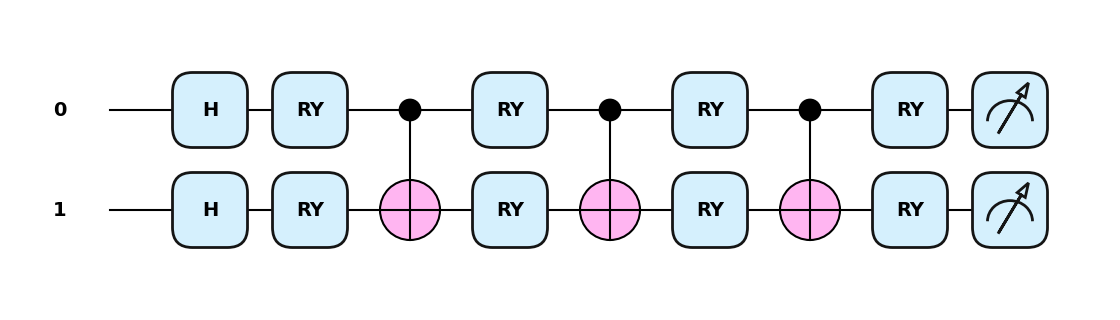


ASCII decomposed circuit (basic gates):
0: ──H──RY(0.86)──╭●──RY(0.63)─╭●──RY(0.21)─╭●──RY(0.09)─┤  <Z>
1: ──H──RY(-1.45)─╰X──RY(0.83)─╰X──RY(0.46)─╰X──RY(0.87)─┤  <Z>


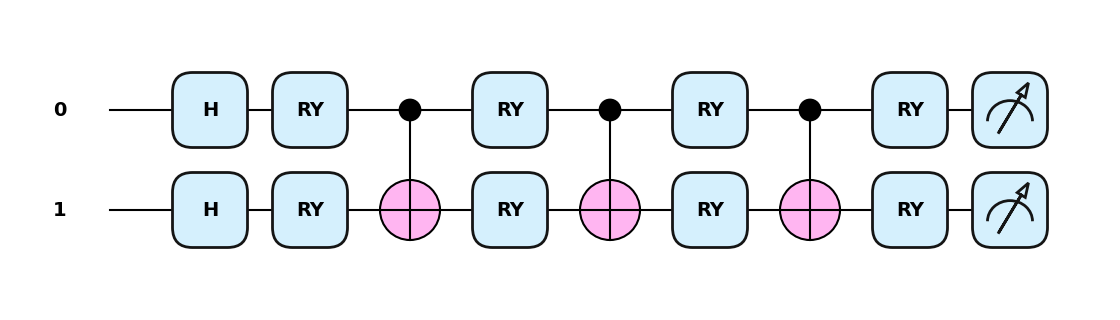

In [11]:
if USE_QUANTUM:
    try:
        draw_qnode_circuit_example(n_qubits=N_QUBITS, q_depth=Q_DEPTH, max_layers=None, seed=0)
    except Exception as exc:
        print('Quantum preview skipped:', exc)
else:
    print('Quantum preview skipped (USE_QUANTUM=False)')


In [12]:
# Preview model (if buildable) before training
try:
    preview_model = build_model(config, class_names, dataloaders, device)
    print_model_summary(preview_model)
except Exception as exc:
    print('Preview model summary skipped:', exc)


Sequential(
  (0): Linear(in_features=512, out_features=2, bias=True)
  (1): ReLU()
  (2): <Quantum Torch Layer: func=circuit>
  (3): Linear(in_features=2, out_features=2, bias=True)
)
Total params: 1,038
Trainable params: 1,038
Classical params: 1,032
Quantum params: 6


5. Model Compilation & Training Lifecycle

This is the core computational phase of the pipeline. Depending on your configuration, this executes either:
1. Direct End-to-End Training: Standard gradient descent applied universally across the classical backbone (e.g., Spectrogram CNN) and chosen classification head.
2. Two-Stage Fine-Tuning: Pre-trains the classical feature extractor on a unified embedding space, freezes the backbone, and isolates the optimization process onto the terminal classification layer (often used for isolating Quantum Advantage in Hybrid models).

The best_model dictionary yields the checkpoint with the highest validation accuracy, circumventing overfitting concerns.

In [13]:
history_stage1 = {}
history_stage2 = {}
final_acc = None
best_model = None

if FINE_TUNING and BASE_MODEL == 'emb_resnet18':
    ft_cfg = FineTuneConfig(
        representation=BASE_MODEL,
        n_qubits=N_QUBITS,
        q_depth=Q_DEPTH,
        pretrain_epochs=EPOCHS_PRETRAIN,
        finetune_epochs=EPOCHS_FINETUNE,
        learning_rate_pretrain=LR_PRETRAIN,
        learning_rate_finetune_classical=LR_FINETUNE,
        learning_rate_finetune_quantum=LR_FINETUNE,
        backbone_dir=str(Path(DATA_ROOT) / 'Models' / 'backbone'),
        batch_size=BATCH_SIZE,
        device_override=None,
    )
    stage1_model, history_stage1, checkpoint = pretrain_backbone_and_embedding(
        dataloaders, dataset_sizes, class_names, ft_cfg, representation_tag=BASE_MODEL
    )
    head_type = 'quantum' if USE_QUANTUM else 'classical'
    best_model, history_stage2, final_acc = finetune_head_only(
        checkpoint, dataloaders, dataset_sizes, class_names, ft_cfg, head_type=head_type,
        representation_tag=BASE_MODEL
    )
else:
    best_model = build_model(config, class_names, dataloaders, device=device)
    best_model, history_stage1 = train_model(
        best_model, dataloaders, dataset_sizes, device, config['num_epochs'], config['learning_rate'], config['model_dir']
    )
    final_acc = history_stage1.get('test_acc', [0])[-1] if history_stage1.get('test_acc') else 0
print('Final test acc estimate:', f'{final_acc:.4f}')


Epoch 1/25
------------------------------


train 1/25:   0%|          | 0/223 [00:00<?, ?it/s]

train Loss: 0.5764  Acc: 0.8212  F1: 0.8209


test 1/25:   0%|          | 0/64 [00:00<?, ?it/s]

test Loss: 0.5096  Acc: 0.8976  F1: 0.8973

Epoch 2/25
------------------------------


...

test Loss: 0.2162  Acc: 0.9429  F1: 0.9429

Epoch 25/25
------------------------------


train 25/25:   0%|          | 0/223 [00:00<?, ?it/s]

train Loss: 0.2127  Acc: 0.9488  F1: 0.9488


test 25/25:   0%|          | 0/64 [00:00<?, ?it/s]

test Loss: 0.2161  Acc: 0.9429  F1: 0.9429

History saved to /content/drive/MyDrive/CREMAD/Models/emb_resnet18/emb_resnet18_quantum/run_03-16_02-26-03/history.json
Metrics saved to /content/drive/MyDrive/CREMAD/Models/emb_resnet18/emb_resnet18_quantum/run_03-16_02-26-03/metrics.json
Final test acc estimate: 0.9429


7. Architectural Introspection

Structural summary verifying computational depth, frozen layers, and total trainable parameters allocated between classical layers and the parameterized quantum layers (if toggled).

In [25]:
# Model summary
print_model_summary(best_model)


Sequential(
  (0): Linear(in_features=512, out_features=2, bias=True)
  (1): ReLU()
  (2): <Quantum Torch Layer: func=circuit>
  (3): Linear(in_features=2, out_features=2, bias=True)
)
Total params: 1,038
Trainable params: 1,038
Classical params: 1,032
Quantum params: 6


In [24]:
# Load utilities
from src.quantum_weights import (
   extract_quantum_weights,
   summarize_quantum_weights,
   find_classical_to_quantum_mapper
)

# Confirm output summaries natively support Colab print buffers cleanly
print("Weights Summary:", summarize_quantum_weights(best_model))
print("Classical projection:", find_classical_to_quantum_mapper(best_model))


Weights Summary: {'weights': {'name': 'weights', 'shape': (3, 2), 'dtype': 'torch.float32', 'min': 1.2158055305480957, 'max': 6.303520202636719, 'mean': 3.3877274990081787, 'std': 2.321847438812256, 'first_few_values': [6.262232780456543, 2.3613998889923096, 1.2158055305480957, 1.3635916709899902, 6.303520202636719]}}
Classical projection: Linear(in_features=512, out_features=2, bias=True)


Saved plot to /content/drive/MyDrive/CREMAD/Models/emb_resnet18/emb_resnet18_quantum/run_03-16_02-26-03/stage1_metrics.png


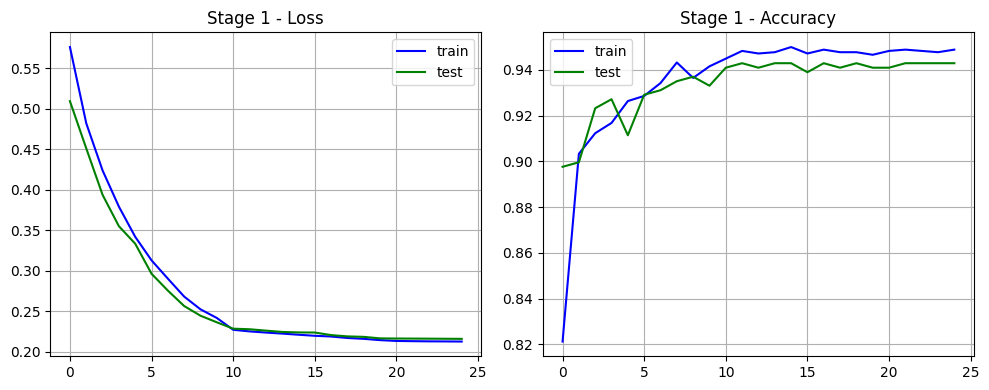

In [15]:
def plot_history(history, title, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    for phase, color in [('train','blue'), ('test','green')]:
        if f'{phase}_loss' in history:
            axes[0].plot(history[f'{phase}_loss'], label=f'{phase}', color=color)
        if f'{phase}_acc' in history:
            axes[1].plot(history[f'{phase}_acc'], label=f'{phase}', color=color)
    axes[0].set_title(f'{title} - Loss'); axes[1].set_title(f'{title} - Accuracy')
    for ax in axes:
        ax.legend(); ax.grid(True)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print('Saved plot to', save_path)
    plt.show()

plot_history(history_stage1, 'Stage 1', save_path=Path(config['model_dir'])/'stage1_metrics.png')
if history_stage2:
    plot_history(history_stage2, 'Stage 2', save_path=Path(config['model_dir'])/'stage2_metrics.png')


6. Evaluation & Inference Profiling

Post-training evaluation iterates through the withheld Validation and Test PyTorch generators using the finalized best_model. Accuracy and weighted F1-Scores are cataloged natively while confusion matrices expose class-specific prediction biases (e.g. predicting Anger over Disgust).

In [16]:
metrics = {}
if 'val' in dataloaders:
    metrics['val'] = evaluate_model(best_model, dataloaders['val'], class_names, device, config['model_dir'], split_name='val')
if 'test' in dataloaders:
    metrics['test'] = evaluate_model(best_model, dataloaders['test'], class_names, device, config['model_dir'], split_name='test')
for split, vals in metrics.items():
    acc = vals.get('accuracy', 0)
    f1 = vals.get('f1_weighted', 0)
    print(f'{split.upper()} accuracy: {acc:.4f}, F1: {f1:.4f}')
print(metrics)


Evaluating (val):   0%|          | 0/61 [00:00<?, ?it/s]

VAL metrics saved to /content/drive/MyDrive/CREMAD/Models/emb_resnet18/emb_resnet18_quantum/run_03-16_02-26-03/val_metrics.json
VAL Accuracy: 0.9397 | F1: 0.9397
Confusion matrix saved to /content/drive/MyDrive/CREMAD/Models/emb_resnet18/emb_resnet18_quantum/run_03-16_02-26-03/confusion_matrix_val.png


Evaluating (test):   0%|          | 0/64 [00:00<?, ?it/s]

TEST metrics saved to /content/drive/MyDrive/CREMAD/Models/emb_resnet18/emb_resnet18_quantum/run_03-16_02-26-03/test_metrics.json
TEST Accuracy: 0.9429 | F1: 0.9429
Confusion matrix saved to /content/drive/MyDrive/CREMAD/Models/emb_resnet18/emb_resnet18_quantum/run_03-16_02-26-03/confusion_matrix_test.png
VAL accuracy: 0.9397, F1: 0.9397
TEST accuracy: 0.9429, F1: 0.9429
{'val': {'accuracy': 0.9397089397089398, 'precision_weighted': 0.9398861355631395, 'recall_weighted': 0.9397089397089398, 'f1_weighted': 0.9396959044240687}, 'test': {'accuracy': 0.9429133858267716, 'precision_weighted': 0.9429751809881098, 'recall_weighted': 0.9429133858267716, 'f1_weighted': 0.9429113948576854}}


8. Quantum Circuit & Weight Inspection (Hybrids Only)

When USE_QUANTUM=True, standard structural summaries fail to capture the nuances of the variational quantum circuits (VQCs). The utilities below, invoked from src.quantum_weights, non-destructively traverse the trained model footprint to extract and interpret the quantum domain parameters without risking parameter mutation or requiring costly retraining.
- Weights Summary: Reports dimensional profiles and statistical bounds of the trainable quantum gates.
- Classical Projection Layer: Isolates the terminal classical dense layer (e.g. nn.Linear) mapped logically immediately prior to feature embedding within the VQC.
- Circuit Re-generation: Given a default dummy configuration scalar (), this visually restructures the model's underlying PennyLane QNode layers. Note: this visualization is purely documentary to expose gate topography (AngleEmbedding, Entangling clusters) and does not map to inference validation instances.

--- Model Quantum Weights Summary ---
{
  "weights": {
    "name": "weights",
    "shape": [
      3,
      2
    ],
    "dtype": "torch.float32",
    "min": 1.2158055305480957,
    "max": 6.303520202636719,
    "mean": 3.3877274990081787,
    "std": 2.321847438812256,
    "first_few_values": [
      6.262232780456543,
      2.3613998889923096,
      1.2158055305480957,
      1.3635916709899902,
      6.303520202636719
    ]
  }
}

--- Classical-to-Quantum Projection Layer ---
Linear(in_features=512, out_features=2, bias=True)

--- Quantum Circuit Topology Reconstructed ---
ASCII circuit diagram (TorchLayer):
0: ─╭AngleEmbedding(M0)─╭BasicEntanglerLayers(M1)─┤  <Z>
1: ─╰AngleEmbedding(M0)─╰BasicEntanglerLayers(M1)─┤  <Z>

M0 = 
tensor([0.5000, 0.5000])
M1 = 
[[6.262233  2.3614   ]
 [1.2158055 1.3635917]
 [6.30352   2.8198133]]


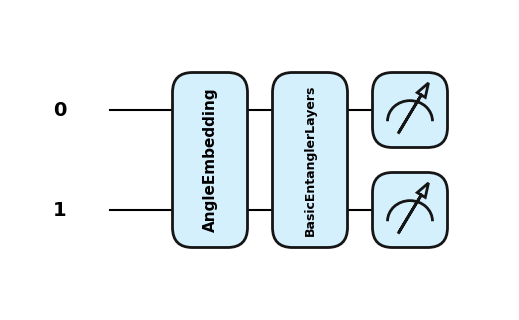

In [44]:

# --- QUANTUM INSPECTION UTILITIES ---
if "USE_QUANTUM" in globals() and USE_QUANTUM:
    try:
        from quantum_weights import (
            summarize_quantum_weights,
            find_classical_to_quantum_mapper,
            draw_quantum_circuit_from_model
        )
        import json

        # Print summarized parameter metadata mapping the active quantum module footprint
        print("--- Model Quantum Weights Summary ---")
        print(json.dumps(summarize_quantum_weights(best_model), indent=2))

        # Identify the classical transition gateway boundary feeding the QNode
        print("\n--- Classical-to-Quantum Projection Layer ---")
        print(find_classical_to_quantum_mapper(best_model))

        # Structurally dissect and draw the underlying quantum topography
        print("\n--- Quantum Circuit Topology Reconstructed ---")
        # This purely outlines structure, relying on a generalized dummy scalar representation
        draw_quantum_circuit_from_model(best_model, style="pennylane")

    except Exception as exc:
        print(f"Quantum structural recap failed: {exc}")
else:
    print("Quantum structural recap skipped (USE_QUANTUM=False or omitted).")

### 8.1 Export Quantum Artifacts for Hardware Verification

The following block extracts the trained quantum parameter weights, infers the metadata/shapes, and captures the *exact* logical feature vector that enters the `QNode` given a small sample from the validation dataloader. This dictionary of artifacts guarantees that the hardware execution module downstream (`hardware_verification.ipynb`) can reproduce identical state preparation and measurement circuits without retraining the base model.

All artifacts are immediately serialized to the `./export_quantum` directory.

In [ ]:
if "USE_QUANTUM" in globals() and USE_QUANTUM:
    try:
        from quantum_weights import export_quantum_artifacts
        import os
        
        print("--- Exporting Quantum Artifacts ---")
        export_dir = "./export_quantum"
        
        # Extract a single sample batch to intercept the actual dimension vector passed to the QNode
        sample_input = None
        if "val_loader" in globals() and val_loader is not None:
            sample_input = next(iter(val_loader))[0][:4] # Minimal 4-sample batch
            print(f"Captured sample validation input shape: {sample_input.shape}")
            
        artifacts = export_quantum_artifacts(best_model, sample_input=sample_input, save_dir=export_dir)
        
        if "error" in artifacts.get("metadata", {}):
            print(f"Warning during metadata extraction: {artifacts['metadata']['error']}")
        else:
            print(f"Successfully mapped {artifacts['metadata'].get('n_qubits', '?')} qubits with depth {artifacts['metadata'].get('q_depth', '?')}")
            
        if artifacts.get("inputs") is not None:
            print(f"Intercepted Quantum circuit input payload shape: {artifacts['inputs'].shape}")
            
        print(f"\nArtifacts successfully written to '{export_dir}':")
        for f in os.listdir(export_dir):
            print(f" - {f}")
            
    except Exception as exc:
        print(f"Failed to export quantum artifacts: {exc}")


Quantum head circuit (decomposed) with trained parameters:


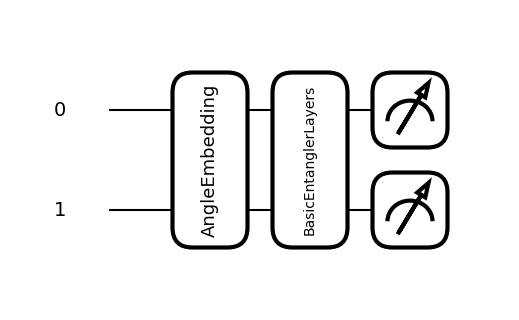

Purity of provided-input state: 1.0000


In [17]:
if USE_QUANTUM:
    try:
        analyze_trained_quantum_head(best_model, device=device, sample_input=None, print_density=True, save_dir=config.get("model_dir"))
    except Exception as exc:
        print('Quantum recap failed:', exc)
else:
    print('Quantum recap skipped (USE_QUANTUM=False)')
